In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
K = 5
phi = np.array([0.1, 0.2, 0.5, 0.1, 0.1])

In [5]:
h = np.linspace(0,1,1000)
b = np.minimum((K * h).astype(int), K-1)
f = np.sqrt((K*h - b) * phi[b])

for k in range(K):
    f[b==k] += np.sum(np.sqrt(phi[:k]))

In [6]:
h_prime = np.linspace(0, np.sum(np.sqrt(phi)), 1000)
edges = np.concatenate(([0], np.cumsum(np.sqrt(phi))))
b_inv = np.minimum(np.searchsorted(edges, h_prime, side="right") - 1, K - 1)

In [7]:
f_inv = (
    b_inv
    + (h_prime - edges[b_inv])**2 / phi[b_inv]
) / K

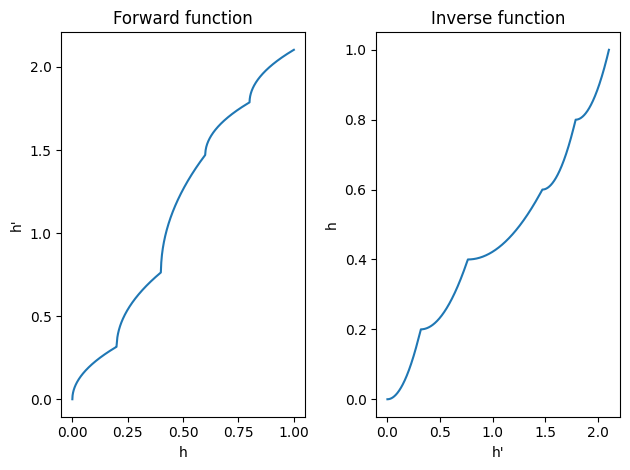

In [9]:
plt.subplot(1, 2, 1)
plt.plot(h, f)
plt.xlabel("h")
plt.ylabel("h'")
plt.title("Forward function")

plt.subplot(1, 2, 2)
plt.plot(h_prime, f_inv)
plt.xlabel("h'")
plt.ylabel("h")
plt.title("Inverse function")

plt.tight_layout()
plt.show()